# 02 — Layout-aware vs. fixed-size chunking

**The claim behind Novelty 1:** chunking at layout-region boundaries beats cutting every *N* tokens.
This notebook tests it on the sample FDA label, two ways:

1. **Structure** — does a chunking keep words, tables and region types intact?
2. **Retrieval** — on 18 labelled questions (`data/eval/metformin_questions.json`), does the right
   passage come back?

**Keeping it fair.** Both chunkings use the same tokenizer, the same 250-token budget and 50-token
overlap. The fixed-size baseline slices the *original* text (it does not decode tokens, so it doesn't
inherit the lowercasing bug our first chunker had). And because fixed chunks are ~5× larger, raw hit@k
flatters them — each "hit" hands the LLM far more text. So we also score **hit within a 1,000-token
context budget**: same amount of reading for the LLM, which strategy gets the answer in?

**Known bias.** One annotator wrote the questions and gold phrases, and two gold phrases were widened
after inspecting results (disclosed in the JSON). 18 questions is small: differences of one or two
questions (±0.06–0.11) are noise.

In [1]:
# Setup — make `config` and `src` importable from notebooks/, quiet the logs, apply the chart style.
import os, sys, warnings
from pathlib import Path
os.environ["TQDM_DISABLE"] = "1"                 # no progress bars in saved outputs
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "notebooks")]
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()                 # hide HuggingFace load chatter
from huggingface_hub.utils import logging as hub_logging
hub_logging.set_verbosity_error()                # ...and Hub server notices

import _viz                                      # shared chart style (notebooks/_viz.py)
_viz.apply()
PDF = ROOT / "data" / "samples" / "metformin_er_fda_label.pdf"

## 1. Two chunkings of the same document

In [2]:
from config import CHUNK_OVERLAP_TOKENS, MAX_CHUNK_TOKENS
from src.chunker import DocumentChunk, _tokenizer, chunk_regions, count_tokens
from src.ingestion import load_pdf_pages
from src.layout import LayoutDetector

pages = load_pdf_pages(PDF)
regions = LayoutDetector().detect_document(pages)
layout_chunks = chunk_regions(regions, doc_id="label")

[LayoutDetector] Loading model: Kwan0/layoutlmv3-base-finetune-DocLayNet-100k
[LayoutDetector] First run downloads ~500MB — be patient.


[LayoutDetector] Ready on cuda. Labels: ['caption', 'footnote', 'formula', 'list_item', 'page_footer', 'page_header', 'picture', 'section_header', 'table', 'text', 'title']


In [3]:
# NAIVE APPROACH — the baseline (what most RAG tutorials do):
#   text = all page text; chunks = every 250 tokens, 50 overlap.
#   No layout, no words, no sentences. We build it properly so the comparison is fair.

def fixed_size_chunks(pages, size: int = MAX_CHUNK_TOKENS,
                      overlap: int = CHUNK_OVERLAP_TOKENS) -> tuple[list[DocumentChunk], str]:
    """Concatenate each page's plain text and cut every `size` tokens (same tokenizer as ours)."""
    text, page_starts = "", []
    for p in pages:
        page_starts.append(len(text))
        text += p.raw_text + "\n"
    offsets = _tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)["offset_mapping"]
    chunks, start = [], 0
    while start < len(offsets):
        end = min(start + size, len(offsets))
        a, b = offsets[start][0], offsets[end - 1][1]
        page = max(i for i, s in enumerate(page_starts) if s <= a)
        chunks.append(DocumentChunk(text[a:b], f"fixed_{len(chunks)}", "label", page, "text",
                                    [0.0, 0.0, 0.0, 0.0], 0, end - start))
        if end == len(offsets):
            break
        start = end - overlap
    return chunks, text


fixed_chunks, full_text = fixed_size_chunks(pages)

import pandas as pd                               # pandas: tables that accompany every chart

pd.DataFrame({
    name: {"chunks": len(ch), "mean tokens": round(sum(c.token_count for c in ch) / len(ch), 1),
           "min tokens": min(c.token_count for c in ch), "max tokens": max(c.token_count for c in ch)}
    for name, ch in [("fixed-size", fixed_chunks), ("layout-aware", layout_chunks)]
}).T

,chunks,mean tokens,min tokens,max tokens
fixed-size,76.0,248.3,121.0,250.0
layout-aware,301.0,52.5,1.0,250.0


## 2. Structure: what does each chunking break?

Three measurements, all "lower is better":
* **Mid-word cuts** — a chunk ends between two letters/digits of one word ("Metfor" | "min").
* **Tables broken apart** — a multi-line table region whose text is not contained whole in any single chunk.
  (For the fixed baseline this also counts tables whose rows were interleaved with neighbouring text by
  plain-text extraction — the table is just as unusable either way.)
* **Chunks mixing a table with prose** — one chunk holds table rows *and* paragraph text, so its
  embedding represents neither.

In [4]:
import re

norm = lambda t: re.sub(r"\s+", " ", t).strip().lower()
nonempty = [r for r in regions if r.text.strip()]          # chunk_regions skips empty regions
region_of = {c.chunk_id: nonempty[int(c.chunk_id.split("_r")[1].split("_")[0])] for c in layout_chunks}


def mid_word_rate(chunks, source_of) -> float:
    """Share of chunk ends that fall inside a word of the source text."""
    bad = 0
    for c in chunks:
        src = source_of(c)
        end = src.find(c.text) + len(c.text)
        bad += end < len(src) and src[end - 1].isalnum() and src[end].isalnum()
    return bad / len(chunks)


def broken_rate(region_list, chunks) -> float:
    """Share of multi-line regions not contained whole in any single chunk."""
    texts = [norm(c.text) for c in chunks]
    multi = [r for r in region_list if "\n" in r.text.strip()]
    return sum(not any(norm(r.text) in t for t in texts) for r in multi) / len(multi)


def distinctive_lines() -> tuple[set[str], set[str]]:
    """
    Table rows and prose lines long and distinctive enough to identify their region.

    A first version matched short rows like "500 mg once daily" — which also occur inside
    paragraphs — and reported 24% of LAYOUT chunks as mixed, which is impossible (each comes
    from one region). So: lines of >= 25 characters, owned by one kind of region only, and
    table rows that never occur inside prose text.
    """
    owner: dict[str, set[str]] = {}
    for r in regions:
        for line in r.text.splitlines():
            if len(norm(line)) >= 25:
                owner.setdefault(norm(line), set()).add(r.label)
    prose_text = " ".join(norm(r.text) for r in regions if r.label in ("text", "list_item"))
    table = {l for l, labs in owner.items() if labs == {"table"} and l not in prose_text}
    prose = {l for l, labs in owner.items() if labs <= {"text", "list_item"} and len(l.split()) >= 6}
    return table, prose


def mixing_rate(chunks) -> float:
    """Share of chunks containing at least one table row AND one prose line."""
    table_lines, prose_lines = distinctive_lines()
    mixed = 0
    for c in chunks:
        t = norm(c.text)
        mixed += any(l in t for l in table_lines) and any(l in t for l in prose_lines)
    return mixed / len(chunks)


tables = [r for r in regions if r.label == "table"]
structure = pd.DataFrame({
    "fixed-size": [mid_word_rate(fixed_chunks, lambda c: full_text), broken_rate(tables, fixed_chunks),
                   broken_rate(regions, fixed_chunks), mixing_rate(fixed_chunks)],
    "layout-aware": [mid_word_rate(layout_chunks, lambda c: region_of[c.chunk_id].text),
                     broken_rate(tables, layout_chunks), broken_rate(regions, layout_chunks),
                     mixing_rate(layout_chunks)],
}, index=["mid-word cuts", "tables broken apart", "any region broken apart", "chunks mixing table + prose"])
structure.round(3)

,fixed-size,layout-aware
mid-word cuts,0.197,0.000
tables broken apart,0.433,0.067
any region broken apart,0.275,0.070
chunks mixing table + prose,0.105,0.000


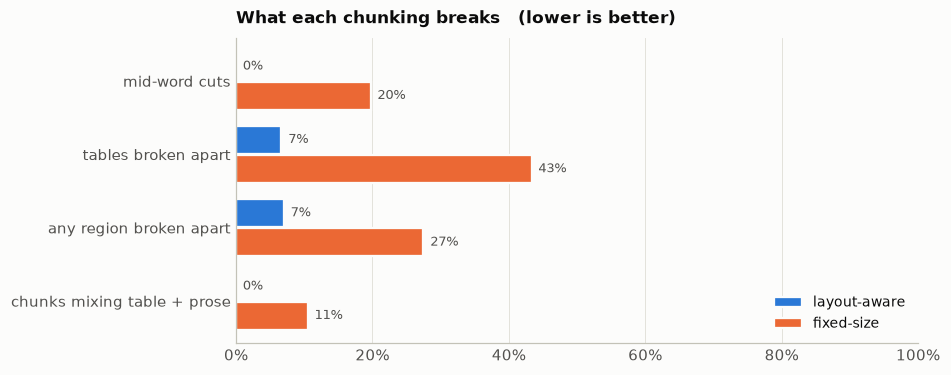

In [5]:
import matplotlib.pyplot as plt                   # matplotlib: static figures that render on GitHub
import numpy as np                                # numpy: bar positions

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(structure))[::-1]
for k, (name, color) in enumerate([("layout-aware", _viz.SERIES[0]), ("fixed-size", _viz.SERIES[1])]):
    vals = structure[name].to_numpy()
    ax.barh(y + (0.2 - 0.4 * k), vals, height=0.38, color=color, edgecolor=_viz.SURFACE,
            linewidth=1.5, label=name)
    for yi, v in zip(y + (0.2 - 0.4 * k), vals):
        ax.text(v + 0.01, yi, f"{v:.0%}", va="center", fontsize=8.5, color=_viz.INK_2)
ax.set_yticks(y, structure.index)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("What each chunking breaks   (lower is better)")
ax.legend(loc="lower right")
plt.show()

## 3. Retrieval: does the right passage come back?

Six variants, each built into its own throwaway ChromaDB with the project's real `VectorStore`,
queried with the same default filter the app uses:

| Variant | What it is |
|---|---|
| fixed-size | the naive baseline |
| fixed-size + rerank | baseline with our cross-encoder re-ranker |
| layout-aware | Novelty 1 chunks, bi-encoder only |
| layout + section prefix | each chunk embedded with its heading prepended — tried and **not shipped** |
| **layout + rerank** | **what the app ships** |
| layout + prefix + rerank | both ideas together |

Metrics over a 20-candidate pool: **hit@1**, **hit@5** (answer in the top 1 / top 5), **MRR** (mean of 1/rank of
the first relevant chunk), and **hit @ 500 / 1,000 tokens** — walk down the ranking, stop when that much context
is used, and ask whether the answer is in. 500 is roughly what the app actually hands the LLM (top 5 of the
shipped configuration ≈ 490 tokens); 1,000 is reported too. Both budgets were fixed before comparing variants.

In [6]:
import json
import tempfile

from src.embedder import Embedder
from src.reranker import Reranker
from src.retriever import build_where_filter
from src.vectorstore import VectorStore

embedder, reranker = Embedder(), Reranker()
QUESTIONS = json.load(open(ROOT / "data" / "eval" / "metformin_questions.json"))["questions"]


def with_section_prefix(chunks: list[DocumentChunk]) -> list[str]:
    """Embedding texts with the most recent heading prepended (the variant that was not shipped)."""
    out, section = [], ""
    for c in chunks:
        if c.region_label == "section_header":
            section = c.text.strip().splitlines()[-1].strip()
        prose = c.region_label not in ("section_header", "page_header", "page_footer")
        out.append(f"{section}\n{c.text}" if prose and section else c.text)
    return out


def build_store(name: str, chunks: list[DocumentChunk], texts: list[str] | None = None) -> VectorStore:
    """Index chunks in a temporary collection; `texts` overrides what gets embedded."""
    store = VectorStore(persist_dir=tempfile.mkdtemp(), collection_name=name)
    store.add_chunks(chunks, embedder.embed_texts(texts or [c.text for c in chunks]))
    return store


import contextlib, io                             # keep embedding progress bars out of the saved notebook

with contextlib.redirect_stderr(io.StringIO()):
    fixed_store = build_store("fixed", fixed_chunks)
    layout_store = build_store("layout", layout_chunks)
    prefix_store = build_store("prefix", layout_chunks, with_section_prefix(layout_chunks))
over = sum(count_tokens(t) > 254 for t in with_section_prefix(layout_chunks))
print(f"prefixed texts over the embedding model's limit (silently truncated): {over}")

[Embedder] Loading model: sentence-transformers/all-MiniLM-L6-v2


[Embedder] Ready on cuda:0. dim=384, max_seq_length=256
[Reranker] Loading model: cross-encoder/ms-marco-MiniLM-L-6-v2


[Reranker] Ready on cuda:0.
[VectorStore] Collection 'fixed' at /tmp/tmpx6xg4ih1 (0 chunks)


[VectorStore] Collection 'layout' at /tmp/tmpdedrr9oj (0 chunks)


[VectorStore] Collection 'prefix' at /tmp/tmphpc589k1 (0 chunks)


prefixed texts over the embedding model's limit (silently truncated): 8


In [7]:
def within_budget(hits, relevant: list[bool], budget: int) -> bool:
    """Walk the ranking, stop once `budget` tokens of context are used; is the answer in?"""
    used = 0
    for h, rel in zip(hits, relevant):
        t = count_tokens(h.text)
        if used and used + t > budget:
            return False
        used += t
        if rel:
            return True
    return False


def evaluate(store: VectorStore, rerank: bool, pool: int = 20) -> tuple[dict, list]:
    """Score one variant on every question; return summary metrics and per-question ranks."""
    ranks, top5_tokens = [], []
    budget_hits = {500: [], 1000: []}
    for item in QUESTIONS:
        hits = store.query(embedder.embed_query(item["q"]), top_k=pool, where=build_where_filter())
        if rerank:
            hits = reranker.rerank(item["q"], hits)
        relevant = [any(g in norm(h.text) for g in item["gold"]) for h in hits]
        ranks.append(relevant.index(True) + 1 if True in relevant else None)
        for budget in budget_hits:
            budget_hits[budget].append(within_budget(hits, relevant, budget))
        top5_tokens.append(sum(count_tokens(h.text) for h in hits[:5]))
    n = len(QUESTIONS)
    metrics = {"hit@1": sum(r == 1 for r in ranks) / n,
               "hit@5": sum(r is not None and r <= 5 for r in ranks) / n,
               "MRR": sum(1 / r for r in ranks if r) / n,
               "hit @ 500 tokens": sum(budget_hits[500]) / n,
               "hit @ 1,000 tokens": sum(budget_hits[1000]) / n,
               "tokens in top 5": sum(top5_tokens) / n}
    return metrics, ranks


VARIANTS = {
    "fixed-size": (fixed_store, False),
    "fixed-size + rerank": (fixed_store, True),
    "layout-aware": (layout_store, False),
    "layout + section prefix": (prefix_store, False),
    "layout + rerank (shipped)": (layout_store, True),
    "layout + prefix + rerank": (prefix_store, True),
}
results, ranks = {}, {}
for name, (store, rr) in VARIANTS.items():
    results[name], ranks[name] = evaluate(store, rr)
results = pd.DataFrame(results).T
results.round(2)

,hit@1,hit@5,MRR,hit @ 500 tokens,"hit @ 1,000 tokens",tokens in top 5
fixed-size,0.61,0.78,0.71,0.72,0.78,1250.00
fixed-size + rerank,0.50,0.89,0.65,0.67,0.78,1249.94
layout-aware,0.28,0.67,0.47,0.83,1.00,218.61
layout + section prefix,0.39,0.72,0.54,0.89,1.00,209.56
layout + rerank (shipped),0.67,0.94,0.79,0.94,1.00,489.50
layout + prefix + rerank,0.67,0.94,0.79,0.94,1.00,492.22


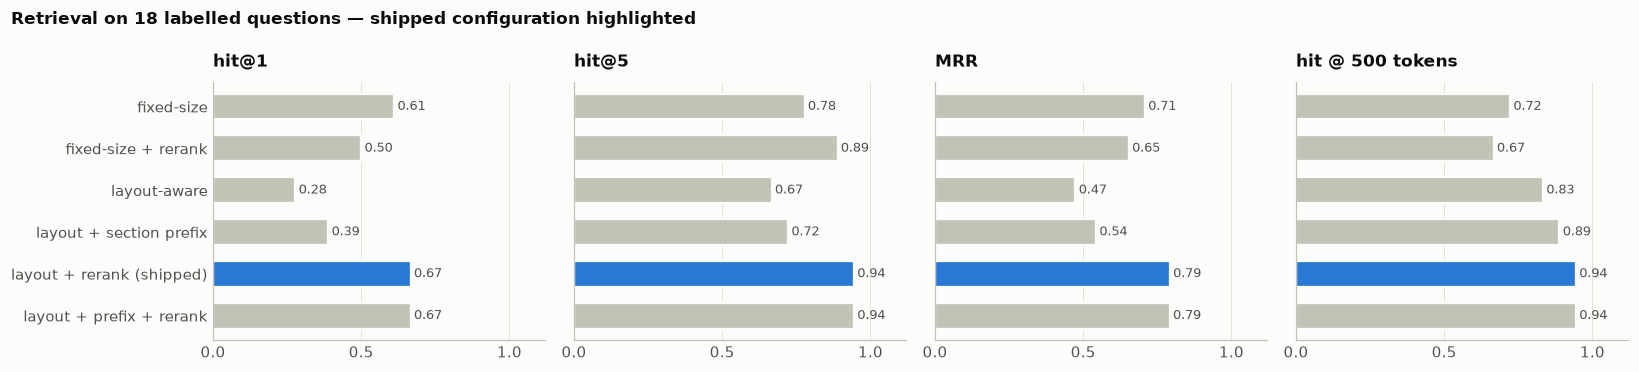

In [8]:
SHIPPED = "layout + rerank (shipped)"
metrics = ["hit@1", "hit@5", "MRR", "hit @ 500 tokens"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for i, (ax, m) in enumerate(zip(axes, metrics)):
    _viz.hbar(ax, list(results.index), list(results[m]), highlight=SHIPPED, xmax=1.12)
    ax.set_title(m)
    ax.set_xticks([0, 0.5, 1.0])
    if i:
        ax.tick_params(labelleft=False)
fig.suptitle("Retrieval on 18 labelled questions — shipped configuration highlighted",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# Rank of the first relevant chunk, per question (None = not in the top 20).
pd.DataFrame(ranks, index=[q["q"] for q in QUESTIONS]).astype("Int64")

,fixed-size,fixed-size + rerank,layout-aware,layout + section prefix,layout + rerank (shipped),layout + prefix + rerank
What is the starting dose?,14,1,1,1,1,1
What is the maximum daily dose?,2,4,1,1,1,1
How quickly can the dose be increased?,1,1,1,1,1,1
When is metformin contraindicated?,16,4,8,1,1,1
Can patients with severe kidney disease take this drug?,6,12,5,4,2,2
Should treatment be started in a patient with an eGFR of 40?,1,1,2,3,2,2
What should be done before an iodinated contrast imaging procedure?,1,1,3,3,1,1
What are the symptoms of lactic acidosis?,2,2,7,7,1,1
What are the risk factors for lactic acidosis?,1,1,10,9,1,1
How should suspected lactic acidosis be treated?,3,2,7,8,1,1


## 4. What only layout-aware chunks can do

Retrieval scores are only half the story. Because every layout-aware chunk knows its region type, a
question can be restricted to **tables** — the fixed-size baseline has no region labels, so this query
cannot even be expressed against it.

In [10]:
from src.retriever import Retriever

retriever = Retriever(embedder, layout_store, reranker=reranker)
question = "How often did patients have diarrhea in the clinical trials?"
for h in retriever.retrieve(question, region_types=["table"])[:3]:
    print(f"p{h.page_num + 1}  [{h.region_label}]  rerank {h.rerank_score:5.2f}  |  {' '.join(h.text.split())[:110]}")

p9  [table]  rerank -5.62  |  Diarrhea 13% 6% Nausea 7% 4%
p15  [table]  rerank -11.05  |  Geometric Mean Ratio (ratio Dose of Dose of with/ without coadministered Coadministered CoadministeredMetformi


## Findings

**Structure — layout-aware wins clearly.** Fixed-size chunking cuts one chunk in five mid-word, breaks
43% of tables apart, and mixes table rows with prose in 11% of chunks. Layout-aware: no mid-word cuts,
no mixing, and the 7% of tables it splits are the ones longer than 250 tokens — split on purpose, with overlap.

**Retrieval — not a simple win, and the nuance is the result.**
1. **Bi-encoder alone, fixed-size beats layout-aware** at hit@1 (0.61 vs 0.28) and MRR (0.71 vs 0.47).
   Fixed chunks are ~5× larger, so each holds more of the answer text; and small chunks suffer most from
   *entity dominance* — every chunk of a one-drug label says "metformin", and a short chunk that is mostly
   the drug name scores as high as the real answer.
2. **At equal context cost, layout-aware wins**: within a 500-token budget 0.83 vs 0.72. Fixed-size's
   hit@k advantage is partly just handing the LLM 5× more text.
3. **Re-ranking fixes layout-aware's weakness** and makes it best on every metric — hit@5 0.94 and
   MRR 0.79 with a top-5 of ~490 tokens, 40% of fixed-size's ~1,250. Re-ranking does *not* rescue fixed-size
   at hit@1 (0.61 → 0.50): the ms-marco re-ranker was trained on short passages, and 250-token chunks that
   straddle several topics are hard for it to score.
4. **Section-heading prefix**: a small gain alone (MRR 0.47 → 0.54), none on top of re-ranking, and 8
   prefixed chunks overflow the embedding model's input. Correctly not shipped.
5. **Capability, not a score**: the table-only query in section 4 returns the adverse-reaction row
   "Diarrhea 13% 6%". Against fixed-size chunks the question cannot be asked at all.

> **INTERVIEW ALERT — "Did layout-aware chunking actually help?"**
> "It keeps structure intact — no words cut, tables whole. For retrieval it's a two-part answer: with a
> bi-encoder alone its small chunks ranked *worse* at hit@1 than fixed-size chunks, because they're
> dominated by the drug name. Paired with a cross-encoder re-ranker it wins on every metric, and gets the
> answer into the LLM's context more often using 40% of the tokens. I only know that because I measured
> both — on 18 questions and one document, so it's evidence, not proof."

**Limits.** 18 questions, one document, one annotator; a difference of one question is ±0.06.

Computed summary:

In [11]:
r = results
print(f"* Structure: fixed-size cuts {structure.loc['mid-word cuts', 'fixed-size']:.0%} of chunks mid-word "
      f"and breaks {structure.loc['tables broken apart', 'fixed-size']:.0%} of tables; layout-aware: "
      f"{structure.loc['mid-word cuts', 'layout-aware']:.0%} and {structure.loc['tables broken apart', 'layout-aware']:.0%}.")
for name in ["fixed-size", "layout-aware", "fixed-size + rerank", SHIPPED]:
    print(f"* {name:26} hit@1 {r.loc[name, 'hit@1']:.2f}  hit@5 {r.loc[name, 'hit@5']:.2f}  "
          f"MRR {r.loc[name, 'MRR']:.2f}  hit@500tok {r.loc[name, 'hit @ 500 tokens']:.2f}  "
          f"(top-5 context ≈ {r.loc[name, 'tokens in top 5']:.0f} tokens)")

* Structure: fixed-size cuts 20% of chunks mid-word and breaks 43% of tables; layout-aware: 0% and 7%.
* fixed-size                 hit@1 0.61  hit@5 0.78  MRR 0.71  hit@500tok 0.72  (top-5 context ≈ 1250 tokens)
* layout-aware               hit@1 0.28  hit@5 0.67  MRR 0.47  hit@500tok 0.83  (top-5 context ≈ 219 tokens)
* fixed-size + rerank        hit@1 0.50  hit@5 0.89  MRR 0.65  hit@500tok 0.67  (top-5 context ≈ 1250 tokens)
* layout + rerank (shipped)  hit@1 0.67  hit@5 0.94  MRR 0.79  hit@500tok 0.94  (top-5 context ≈ 490 tokens)
